In [7]:
import matplotlib.pyplot as plt
import vima, cna
import pandas as pd
import numpy as np
import scanpy as sc
import pickle, gc
%run ../common.py

# Function definitions

In [8]:
def run_vima(ds, samplemeta, pheno, methodname, phenoname, secondary_pheno=None, secondary_phenoname=None):
    Nnull = 10000 if len(ds[0]) < 50000 else 1000
    res, D = vima.association(ds, samplemeta[pheno], 'sid', donorids=samplemeta.donor, Nnull=Nnull, return_full=True, make_umap=False)
    pos = (D.obs.mncoef > 0) & (D.obs.mncoef_fdr <= 0.1)
    neg = (D.obs.mncoef < 0) & (D.obs.mncoef_fdr <= 0.1)
    result = [{'pheno':phenoname, 'method':methodname, 'p':res.p,
            'npos':pos.sum(), 'nneg':neg.sum()}]
    
    if secondary_pheno is not None:
        pos_ix = ds[0].obs.index.astype(str).isin(D.obs.index[pos])
        print(pos_ix.sum())
        if pos_ix.sum() > 10:
            ds_ = [d[pos_ix,:].copy() for d in ds]
            for d_ in ds_:
                sc.pp.neighbors(d_, use_rep='X')
            res, D = vima.association(ds_, samplemeta[secondary_pheno], 'sid', donorids=samplemeta.donor, Nnull=Nnull, return_full=True, make_umap=False)
            pos = (D.obs.mncoef > 0) & (D.obs.mncoef_fdr <= 0.1)
            neg = (D.obs.mncoef < 0) & (D.obs.mncoef_fdr <= 0.1)
            result += [{'pheno':secondary_phenoname, 'method':methodname, 'p':res.p,
                'npos':pos.sum(), 'nneg':neg.sum()}]
        else:
            result += [{'pheno':secondary_phenoname, 'method':methodname, 'p':1,
                'npos':0, 'nneg':0}]
    
    return result


def clustercc(df, cols, pheno, donor, Nnull=10000):
    X = df[cols].values.copy()
    pheno = df[pheno].copy()
    donorids = df[donor].copy()
    mask = ~np.isnan(pheno)
    X = X[mask]; pheno = pheno[mask]; donorids = donorids[mask]
    
    X = np.nan_to_num((X - X.mean(axis=0))/X.std(axis=0))
    y_ = cna.tl._stats.grouplevel_permutation(donorids, pheno, Nnull).astype('float')
    pheno = (pheno - pheno.mean())/pheno.std()
    y_ -= y_.mean(axis=0)
    y_ /= y_.std(axis=0)
    
    ncorrs = X.T.dot(pheno) / len(X)
    nullncorrs = X.T.dot(y_) / len(X)
    pvals = ((np.abs(nullncorrs) >= np.abs(ncorrs)[:,None]).sum(axis=1) + 1)/(Nnull + 1)
    globalp = (((ncorrs**2).sum() <= (nullncorrs**2).sum(axis=0)).sum() + 1)/(Nnull + 1)
    maxcorr = max(np.abs(ncorrs).max(), 0.001)
    print(maxcorr)
    fdr_thresholds = np.arange(maxcorr/10, maxcorr, maxcorr/1000)
    fdr_vals = cna.tl._stats.empirical_fdrs(ncorrs, nullncorrs, fdr_thresholds)
    fdrs = pd.DataFrame({
        'threshold':fdr_thresholds,
        'fdr':fdr_vals,
        'num_detected': [(np.abs(ncorrs)>t).sum() for t in fdr_thresholds]})

    if len(fdrs[fdrs.fdr <= 0.1]) > 0:
        fdr10pt = fdrs[fdrs.fdr <= 0.1].threshold.min()
    else:
        fdr10pt = np.infty
    
    return fdrs, fdr10pt, ncorrs, pvals, globalp

def run_vima_and_clusters(ds, samplemeta, pheno, methodname, phenoname, secondary_pheno=None, secondary_phenoname=None, cluster_key='leiden_1'):
    def run_clusters(d, mypheno, myphenoname):
        sc.tl.leiden(d, resolution=1, key_added='leiden_1')
        ct = pd.crosstab(
            d.obs['sid'], d.obs[cluster_key], 
        )
        ct.index.name = 'sid'
        ct = ct.div(ct.sum(axis=1), axis=0)
        clusts = ct.columns.values
        ct['donor'] = samplemeta['donor']
        ct['pheno'] = samplemeta[mypheno]

        _, fdr10pt, stats, ps, globalp = clustercc(ct, clusts, 'pheno', 'donor', Nnull=10000)
        d.uns['clustercc'] = pd.DataFrame(
            {'corr':stats, 'p':ps, 'globalp':globalp},
            index=pd.Series(clusts, name='cluster'),
        )
        d.uns['clustercc_key'] = cluster_key
        d.uns['clustercc_minp'] = np.min(ps*len(ps))
        d.uns['clustercc_globalp'] = d.uns['clustercc'].globalp

        sig_pos = d.uns['clustercc'][(d.uns['clustercc']['corr'] > fdr10pt)].index.values
        sig_neg = d.uns['clustercc'][(d.uns['clustercc']['corr'] < -fdr10pt)].index.values
        d.obs['sig_pos'] = d.obs[cluster_key].isin(sig_pos)
        d.obs['sig_neg'] = d.obs[cluster_key].isin(sig_neg)
        d.uns['clustercc_npos'] = d.obs.sig_pos.sum()
        d.uns['clustercc_nneg'] = d.obs.sig_neg.sum()
        return [
             {'pheno':myphenoname, 'method':'cluster', 'p':d.uns['clustercc_minp'],
             'npos':d.uns['clustercc_npos'], 'nneg':d.uns['clustercc_nneg']}]
    
    result = run_vima(ds, samplemeta, pheno, methodname, phenoname, secondary_pheno=secondary_pheno, secondary_phenoname=secondary_phenoname)
    result += run_clusters(ds[0], pheno, phenoname)

    if secondary_pheno is not None:
        d_ = ds[0][ds[0].obs.sig_pos].copy()
        if len(d_) > 10:
            sc.tl.neighbors(d_, use_rep='X')
            result += run_clusters(d_, secondary_pheno, secondary_phenoname)
        else:
            result += [{'pheno':secondary_phenoname, 'method':'cluster', 'p':1,
                'npos':0, 'nneg':0}]

    return result

# Assess models

In [9]:
nns = {
    'vima-nocvae-noresnet':run_vima_and_clusters,
    'vima-nosid':run_vima,
    'vima':run_vima
    }

In [53]:
## make samplemetas
samplemetas = {}
# RA
ds = pickle.load(open(f'_models/RA_vima-nocvae-noresnet.pkl', 'rb'))
fullmeta = pd.read_csv('../../RA/BHAM-data/ihc-metadata.csv').set_index('subject_id')[['CTAP']]
fullmeta.index = fullmeta.index.str.replace('V0', '')
fullmeta = pd.merge(fullmeta, pd.get_dummies(fullmeta.CTAP.str.replace(' + ', ''), prefix='', prefix_sep=''),
        left_index=True, right_index=True)
fullmeta['case'] = fullmeta.F | fullmeta.TF | fullmeta.EFM
inourdata = ds[0].obs[['sid','donor']].drop_duplicates()
samplemeta = pd.merge(inourdata, fullmeta, left_on='donor', right_index=True, how='left').set_index('sid', drop=True)
samplemeta['case'] = samplemeta.F | samplemeta.TF | samplemeta.EFM
samplemetas['RA'] = samplemeta

# UC
samplemeta = pd.read_csv('../../UC/UC-data/2024_10_16_UC_Patient_Metadata.csv').rename(columns={'NEW Label':'sid', 'Patient.ID':'donor'}).set_index('sid', drop=True)
samplemeta.donor = samplemeta.donor.astype('str')
samplemeta['case'] = (samplemeta.Status == 'UC').astype('float')
samplemeta.loc[(samplemeta.TNFnow == 'y') | (samplemeta.TNFprior == 'y'), 'case'] = np.nan
samplemeta['TNFprior'] = (samplemeta.TNFprior == 'y').astype('float')
samplemeta.loc[samplemeta.case == 0, 'TNFprior'] = np.nan
samplemetas['UC'] = samplemeta

# ALZ
ds = pickle.load(open(f'_models/ALZ_vima-nocvae-noresnet.pkl', 'rb'))
samplemeta = pd.read_csv('../../ALZ/alz-data/sea-ad_cohort_donor_metadata_encoded_20240924.tsv',
                         sep='\t').set_index('Donor ID', drop=True)
inourdata = ds[0].obs[['sid','donor']].drop_duplicates()
samplemeta = pd.merge(inourdata, samplemeta, left_on='donor', right_index=True, how='left').set_index('sid', drop=True)
samplemeta['case'] = samplemeta['Consensus Clinical Dx (choice=Control)'] != 'Checked'
samplemeta = samplemeta[['donor','case']]
samplemetas['ALZ'] = samplemeta

del ds; gc.collect()

10963

In [ ]:
# run vima and cluster case/control comparisons
import os
resultslist = []
for dsetname in ['ALZ','RA','UC']:
    for nnname, f in nns.items():
        print(dsetname, nnname, end=' ')
        fname = f'_models/{dsetname}_{nnname}.pkl'
        if not os.path.exists(fname):
            continue
        ds = pickle.load(open(fname, 'rb'))
        if dsetname == 'UC':
            resultslist += f(ds, samplemetas[dsetname], 'case', nnname, dsetname, secondary_pheno='TNFprior', secondary_phenoname='TNFi')
        else:
            resultslist += f(ds, samplemetas[dsetname], 'case', nnname, dsetname)
        gc.collect()
results = pd.DataFrame(resultslist)

ALZ vima-nocvae-noresnet computing MAMs
performing association test
P = 0.005994005994005994


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/yakir/Dropbox/py/cna/src/cna/tools/_stats.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Yg = np.array([Y[G==g][0] for g in Gu])


0.47742167311542605
ALZ vima-nosid computing MAMs
performing association test
P = 0.01998001998001998


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


ALZ vima computing MAMs
performing association test
P = 0.004995004995004995


...

computing MAMs
performing association test
P = 0.0027997200279972004
UC vima computing MAMs
performing association test
P = 0.0013998600139986002


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


3682


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:

computing MAMs
performing association test
P = 0.0008999100089991


In [ ]:
# write results to disk
results['total'] = results.npos + results.nneg
results['scaled_total'] = results.total.copy()
results.loc[results.pheno == 'RA', 'scaled_total'] /= results[(results.pheno=='RA')&(results.method=='vima')].total.iloc[0]
results.loc[results.pheno == 'UC', 'scaled_total'] /= results[(results.pheno=='UC')&(results.method=='vima')].total.iloc[0]
results.loc[results.pheno == 'TNFi', 'scaled_total'] /= results[(results.pheno=='TNFi')&(results.method=='vima')].total.iloc[0]
results.loc[results.pheno == 'ALZ', 'scaled_total'] /= results[(results.pheno=='ALZ')&(results.method=='vima')].total.iloc[0]

results['logp'] = -np.log10(results.p)

results.to_csv('_results/ablationresults.csv')

/var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/ipykernel_44330/893824053.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.00475687 0.07399577 1.03611698 1.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  results.loc[results.pheno == 'RA', 'scaled_total'] /= results[(results.pheno=='RA')&(results.method=='vima')].total.iloc[0]


# Collect perplexities (requires benchmark to have been run)

In [18]:
for dset in ['RA','ALZ','UC']:
    print(dset)
    ds = pickle.load(open(f'../{dset}/_results/fingerprints.pkl', 'rb'))
    write_perplexities(dset, ds, f'../{dset}/_results/perplexities.csv')
    print()

RA
           perplexity                                                    \
                count      mean       std       min       25%       50%   
method                                                                    
canvas        20938.0  0.184799  0.092372  0.067833  0.113514  0.168410   
patchavgmm    22497.0  0.130337  0.061819  0.045195  0.081391  0.121802   
stagate      366976.0  0.080927  0.040979  0.050906  0.050906  0.062949   
vima         103450.0  0.238465  0.120584  0.052118  0.154543  0.217135   

                                
                 75%       max  
method                          
canvas      0.239189  0.742669  
patchavgmm  0.169800  0.419408  
stagate     0.098087  0.527217  
vima        0.294242  1.055410  

ALZ
                       perplexity                                          \
                            count      mean       std       min       25%   
method                                                                      
canv

In [19]:
allperplexities = pd.concat([
    pd.read_csv(f'../{dset}/_results/perplexities.csv')
    for dset in ['RA','ALZ','UC']
])
allperplexities.to_csv('_results/allperplexities.csv')

# Unused

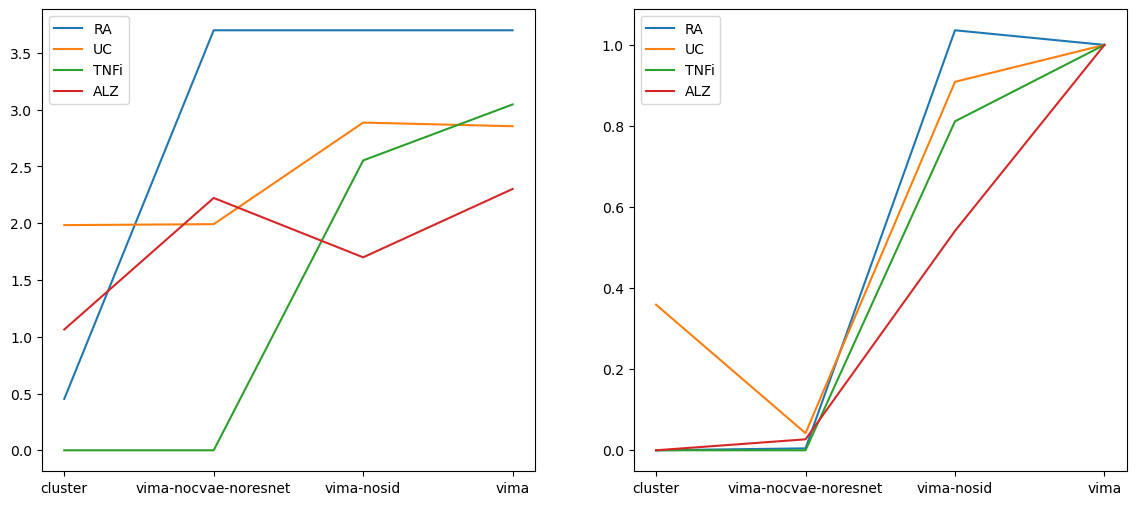

In [11]:
methods = ['cluster',
        #    'vima-nosid-noresnet',
           'vima-nocvae-noresnet',
        #    'vima-nocvae',
           'vima-nosid',
           'vima']

fig, axs = plt.subplots(1, 2, figsize=(14,6))
for pheno in ['RA','UC','TNFi','ALZ']:
    toplot = results[results.pheno == pheno].set_index('method')
    axs[0].plot(toplot.loc[methods].logp, label=pheno)
axs[0].legend()

for pheno in ['RA','UC','TNFi','ALZ']:
    toplot = results[results.pheno == pheno].set_index('method')
    axs[1].plot(toplot.loc[methods].scaled_total, label=pheno)
axs[1].legend()
plt.show()

In [10]:
markers = ['o', 'x', 's', '^']  # circle, x, square, triangle

for pheno in ['RA', 'UC', 'TNFi', 'ALZ']:
    toplot = results[results.pheno == pheno].set_index('method')
    toplot = toplot.loc[['cluster', 'vima-nocvae-noresnet', 'vima-nocvae', 'vima']]

    plt.plot(toplot.logp, toplot.scaled_total, label=pheno,
             color=plt.cm.tab10(['RA', 'UC', 'TNFi', 'ALZ'].index(pheno)))
    
    # Plot each point with its own marker
    for i, (method, row) in enumerate(toplot.iterrows()):
        plt.plot(
            row.logp,
            row.scaled_total,
            marker=markers[i],
            linestyle='-',  # to connect the points
            color=plt.cm.tab10(['RA', 'UC', 'TNFi', 'ALZ'].index(pheno)),  # consistent color per pheno
            label=None
        )

plt.legend()
plt.xlabel("logp")
plt.ylabel("scaled_total")
plt.show()


KeyError: "['vima-nocvae'] not in index"

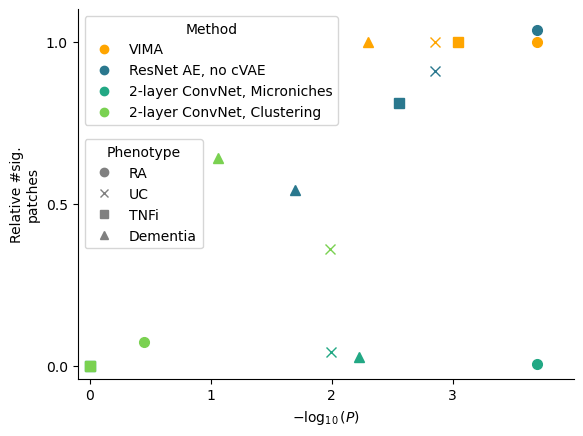

In [7]:
import matplotlib.lines as mlines
import seaborn as sns

methods = [
        'vima',
        'vima-nosid',
        'vima-nocvae-noresnet',
        'cluster',
           ]
methodnames = {
    'cluster':'2-layer ConvNet, Clustering',
    'vima-nocvae-noresnet':'2-layer ConvNet, Microniches',
    'vima-nosid':'ResNet AE, no cVAE',
    'vima':'VIMA'}

phenos = ['RA', 'UC', 'TNFi', 'Dementia']

markers = ['o', 'x', 's', '^']  # circle, x, square, triangle

palette = sns.color_palette("viridis", n_colors=4)
palette[0] = (1.0, 0.647, 0.0)

for method in methods:
    toplot = results[results.method == method].set_index('pheno')
    toplot.index = toplot.index.str.replace('ALZ','Dementia')
    toplot = toplot.loc[phenos]
    
    # Plot each point with its own marker
    for i, (pheno, row) in enumerate(toplot.iterrows()):
        plt.plot(
            row.logp,
            row.scaled_total,
            marker=markers[i], markersize=7,
            color=palette[methods.index(method)],  # consistent color per pheno
            label=methodnames[method] if i == 0 else None
        )

# Legend for method (color)
method_handles = [
    mlines.Line2D([], [], color=palette[i], marker='o', linestyle='None', label=methodnames[m])
    for i, m in enumerate(methods)
]

# Legend for pheno (marker)
pheno_handles = [
    mlines.Line2D([], [], color='gray', marker=markers[i], linestyle='None', label=phenos[i])
    for i in range(len(phenos))
]

# Add both legends
first_legend = plt.legend(handles=method_handles, title='Method', loc='upper left')
plt.gca().add_artist(first_legend)  # keep the first legend

plt.legend(handles=pheno_handles, title='Phenotype', loc='center left')

plt.xlabel("$-\\log_{10}(P)$")
plt.ylabel("Relative #sig.\npatches")
plt.xticks([0,1,2,3])
plt.yticks([0,0.5,1])
plt.xlim(-0.1,4)
plt.ylim(-0.04,1.1)
plt.gca().spines[['top','right']].set_visible(False)
plt.savefig('/Users/yakir/Desktop/temp.png', dpi=500)
plt.show()

AttributeError: 'Series' object has no attribute 'logp'

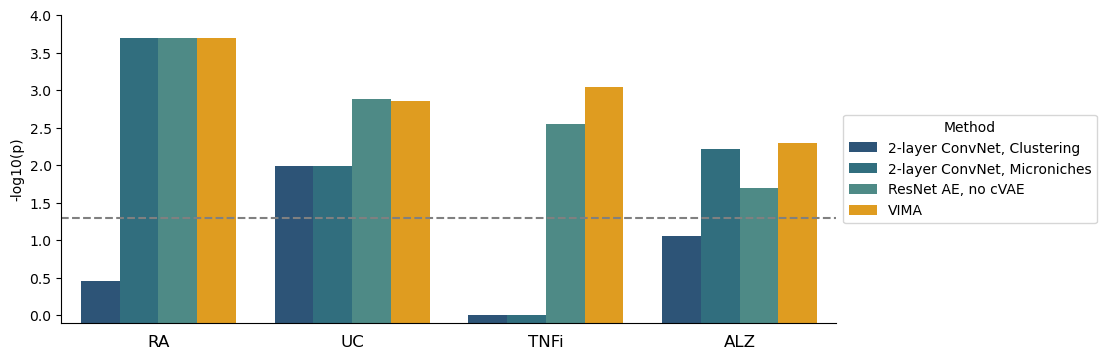

In [ ]:


import seaborn as sns
df_melted = results[results.method.isin(methodnames.keys())].copy()
df_melted['logp'] = -np.log10(results.p)+0.1
df_melted['total_toplot'] = df_melted.scaled_total+0.1
plt.figure(figsize=(10, 4))
palette = sns.color_palette("crest", n_colors=len(df_melted['method'].unique()))[::-1]
palette[-1] = (1.0, 0.647, 0.0)
palette2 = sns.color_palette("flare", n_colors=len(df_melted['method'].unique()))[::-1]
palette2[-1] = (1.0, 0.647, 1)
ax = sns.barplot(data=df_melted, x='pheno', y='logp', hue='method', palette=palette,
                 order=['RA','UC','TNFi','ALZ'],
                 hue_order=methodnames.keys())
handles, labels = ax.get_legend_handles_labels()
new_labels = [methodnames[label] for label in labels]
ax.legend(handles, new_labels, title='Method', fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))

plt.axhline(-np.log10(0.05)+0.1, ls='--', color='gray')
yticks = plt.gca().get_yticks()
plt.gca().set_yticks(yticks + 0.1)
plt.gca().set_yticklabels([f'{tick:.1f}' for tick in yticks], fontsize=10)
plt.ylabel('-log10(p)', fontsize=10)
# plt.yticks([0.1,1.1,2.1,3.1,4.1], [0,1,2,3,4])
plt.xlabel('')
ax.tick_params(axis='x', which='both', length=0)
ax.spines[['right','top']].set_visible(False)
# plt.ylim(0,3.7)
plt.xticks(fontsize=12, y=-0.02)

plt.show()

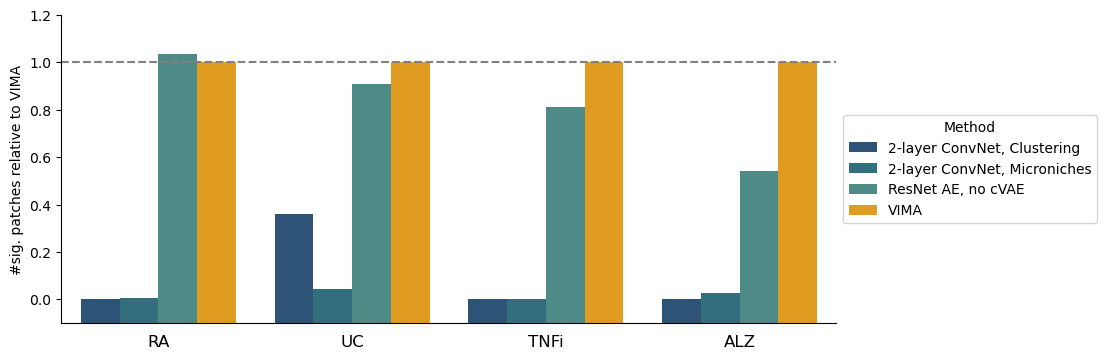

In [129]:
methodnames = {
    'cluster':'2-layer ConvNet, Clustering',
    'vima-nocvae-noresnet':'2-layer ConvNet, Microniches',
    # 'vima-nocvae':'ResNet AE, no cVAE',
    'vima-nosid':'ResNet AE, no cVAE',
    'vima':'VIMA'}

import seaborn as sns
df_melted = results[results.method.isin(methodnames.keys())].copy()
df_melted['logp'] = -np.log10(results.p)+0.1
df_melted['total_toplot'] = df_melted.scaled_total+0.1
plt.figure(figsize=(10, 4))
palette = sns.color_palette("crest", n_colors=len(df_melted['method'].unique()))[::-1]
palette[-1] = (1.0, 0.647, 0.0)
palette2 = sns.color_palette("flare", n_colors=len(df_melted['method'].unique()))[::-1]
palette2[-1] = (1.0, 0.647, 1)
ax = sns.barplot(data=df_melted, x='pheno', y='total_toplot', hue='method', palette=palette,
                 order=['RA','UC','TNFi','ALZ'],
                 hue_order=methodnames.keys())
handles, labels = ax.get_legend_handles_labels()
new_labels = [methodnames[label] for label in labels]
ax.legend(handles, new_labels, title='Method', fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))

plt.axhline(1.1, ls='--', color='gray')
yticks = plt.gca().get_yticks()
plt.gca().set_yticks(yticks + 0.1)
plt.gca().set_yticklabels([f'{tick:.1f}' for tick in yticks], fontsize=10)
plt.ylabel('#sig. patches relative to VIMA', fontsize=10)
# plt.yticks([0.1,1.1,2.1,3.1,4.1], [0,1,2,3,4])
plt.xlabel('')
ax.tick_params(axis='x', which='both', length=0)
ax.spines[['right','top']].set_visible(False)
# plt.ylim(0,3.7)
plt.xticks(fontsize=12, y=-0.02)

plt.show()

In [119]:
df_melted

,pheno,method,p,npos,nneg,total,scaled_total,logp,total_toplot
0,ALZ,vima-nocvae-noresnet,0.005994,505,984,1489,0.027027,2.422283,-0.281081
1,ALZ,cluster,0.086391,0,0,0,0.000000,1.263530,-0.200000
2,ALZ,vima-nosid,0.019980,13649,16161,29810,0.541085,1.899404,-1.823255
4,ALZ,vima,0.004995,33342,21751,55093,1.000000,2.501464,-3.200000
5,RA,vima-nocvae-noresnet,0.000200,13,14,27,0.004757,3.899013,-0.214271
6,RA,cluster,0.352765,0,0,0,0.000000,0.652515,-0.200000
7,RA,vima-nosid,0.000200,2418,3463,5881,1.036117,3.899013,-3.308351
9,RA,vima,0.000200,2294,3382,5676,1.000000,3.899013,-3.200000
10,UC,vima-nocvae-noresnet,0.010199,3,461,464,0.042121,2.191443,-0.326362
11,TNFi,vima-nocvae-noresnet,1.000000,0,0,0,0.000000,0.200000,-0.200000


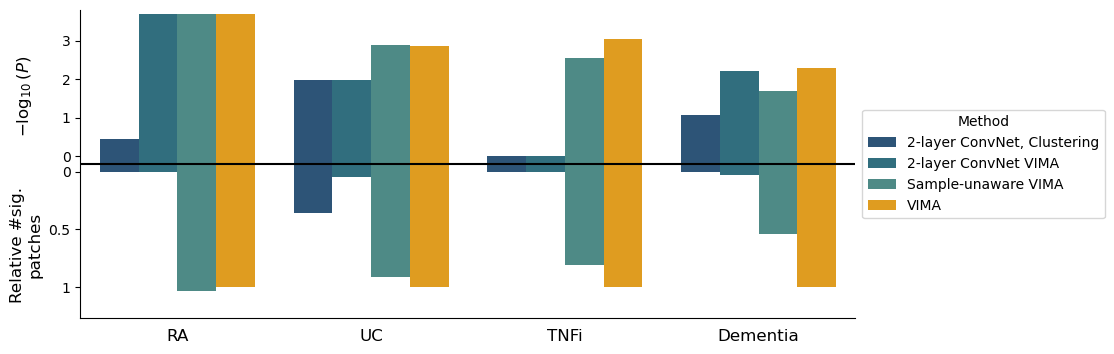

In [188]:
methodnames = {
    'cluster':'2-layer ConvNet, Clustering',
    'vima-nocvae-noresnet':'2-layer ConvNet VIMA',
    # 'vima-nocvae':'ResNet AE, no cVAE',
    'vima-nosid':'Sample-unaware VIMA',
    'vima':'VIMA'}

import seaborn as sns
df_melted = results[results.method.isin(methodnames.keys())].copy()
df_melted['logp'] = -np.log10(results.p)+0.2
df_melted['total_toplot'] = -df_melted.scaled_total*3-0.2
df_melted.pheno = df_melted.pheno.str.replace('ALZ','Dementia')
plt.figure(figsize=(10, 4))
palette = sns.color_palette("crest", n_colors=len(df_melted['method'].unique()))[::-1]
palette[-1] = (1.0, 0.647, 0.0)
palette2 = sns.color_palette("flare", n_colors=len(df_melted['method'].unique()))[::-1]
palette2[-1] = (1.0, 0.647, 1)
ax = sns.barplot(data=df_melted, x='pheno', y='logp', hue='method', palette=palette,
                 order=['RA','UC','TNFi','Dementia'],
                 hue_order=methodnames.keys())
ax = sns.barplot(data=df_melted, x='pheno', y='total_toplot', hue='method', palette=palette,
                 order=['RA','UC','TNFi','Dementia'],
                 hue_order=methodnames.keys(), legend=None, ax=ax)
handles, labels = ax.get_legend_handles_labels()
new_labels = [methodnames[label] for label in labels]
ax.legend(handles, new_labels, title='Method', fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))

plt.axhline(0, ls='-', color='black')
yticks = plt.gca().get_yticks()
plt.gca().set_yticks(yticks + 0.1)
plt.gca().set_yticklabels([f'{tick:.1f}' for tick in yticks], fontsize=10)
plt.ylabel('$-\\log_{10}(P)$', fontsize=12, loc='top')
plt.yticks([-3.2, -1.7, -0.2, 0.2,1.2,2.2,3.2], [1, 0.5, 0, 0, 1, 2, 3])
plt.xlabel('')
ax.tick_params(axis='x', which='both', length=0)
ax.spines[['right','top']].set_visible(False)
plt.ylim(-4,4)
plt.xticks(fontsize=12, y=-0.02)

ax.yaxis.set_label_coords(-0.06, 0.85)
ax.text(-0.07, 0.05, 'Relative #sig.\npatches', transform=ax.transAxes,
        rotation='vertical', fontsize=12, va='bottom', ha='center')


plt.show()

In [ ]:
from importlib import reload
reload(vima.cc)
dsetname = 'UC'
methodname = 'vima-nocvae'

ds = pickle.load(open(f'_results/{dsetname}_{methodname}.pkl', 'rb'))

samplemeta = pd.read_csv('../../UC/UC-data/2024_10_16_UC_Patient_Metadata.csv').rename(columns={'NEW Label':'sid', 'Patient.ID':'donor'}).set_index('sid', drop=True)
samplemeta.donor = samplemeta.donor.astype('str')
samplemeta['case'] = (samplemeta.Status == 'UC').astype('float')
samplemeta.loc[(samplemeta.TNFnow == 'y') | (samplemeta.TNFprior == 'y'), 'case'] = np.nan

res, D = vima.cc.association(ds, samplemeta.case, 'sid', donorids=samplemeta.donor, Nnull=100, make_umap=False, return_full=True)
(D.obs.mncoef_fdr <= 0.1).sum()

computing MAMs
performing association test
P = 0.009900990099009901
Gamma p-value = 0.0023974814637420794


/Users/yakir/Dropbox/py/vima/src/vima/cc.py:88: UserWarning: global association p-value attained minimal possible value. Consider increasing Nnull
  warnings.warn('global association p-value attained minimal possible value. '+\
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


10637

In [ ]:
dsetname = 'ALZ'
methodname = 'vima-nocvae-noresnet'

ds = pickle.load(open(f'_results/{dsetname}_{methodname}.pkl', 'rb'))

# change samplemeta so that each row is a sample rather than a donor
samplemeta = pd.read_csv('../../ALZ/alz-data/sea-ad_cohort_donor_metadata_encoded_20240924.tsv',
                         sep='\t').set_index('Donor ID', drop=True)
inourdata = ds[0].obs[['sid','donor']].drop_duplicates()
samplemeta = pd.merge(inourdata, samplemeta, left_on='donor', right_index=True, how='left').set_index('sid', drop=True)
samplemeta['case'] = samplemeta['Consensus Clinical Dx (choice=Control)'] != 'Checked'
samplemeta = samplemeta[['donor','case']]

res, D = vima.association(ds, samplemeta.case, 'sid', donorids=samplemeta.donor, Nnull=1000, make_umap=False, return_full=True)
(D.obs.mncoef_fdr <= 0.1).sum()

FileNotFoundError: [Errno 2] No such file or directory: '_results/ALZ_vima-nocvae.pkl'

1489

In [ ]:
dsetname = 'RA'
methodname = 'vima-nocvae-noresnet'

ds = pickle.load(open(f'_results/{dsetname}_{methodname}.pkl', 'rb'))

fullmeta = pd.read_csv('../../RA/BHAM-data/ihc-metadata.csv').set_index('subject_id')[['CTAP']]
fullmeta.index = fullmeta.index.str.replace('V0', '')
fullmeta = pd.merge(fullmeta, pd.get_dummies(fullmeta.CTAP.str.replace(' + ', ''), prefix='', prefix_sep=''),
        left_index=True, right_index=True)
fullmeta['case'] = fullmeta.F | fullmeta.TF | fullmeta.EFM
inourdata = ds[0].obs[['sid','donor']].drop_duplicates()
samplemeta = pd.merge(inourdata, fullmeta, left_on='donor', right_index=True, how='left').set_index('sid', drop=True)
samplemeta['case'] = samplemeta.F | samplemeta.TF | samplemeta.EFM

res, D = vima.association(ds, samplemeta.case, 'sid', donorids=samplemeta.donor, Nnull=10000, make_umap=False, return_full=True)

computing MAMs
performing association test
P = 0.00019998000199980003
Gamma p-value = 0.025763126468523523


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [ ]:
for d in ds[:1]:
    d_ = d.copy()
    sc.tl.leiden(d_, resolution=1, key_added='leiden_1')
    test_cluster_cc(d_, samplemeta)
    

/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Using leiden_1 for clustering
0.5210166255183524


/Users/yakir/Dropbox/py/cna/src/cna/tools/_stats.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Yg = np.array([Y[G==g][0] for g in Gu])


done cluster analysis
